<a href="https://colab.research.google.com/drive/1cRQdXPt8U_oiJyWpT_GQTWJXrpYppNwr"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5 - Kernel Methods - homework by Łukasz Grzegrzółka

### Notebook author: Szymon Nowakowski

### Polynomial Kernel Example

Recall the general form of a polynomial kernel is:

$$
K(x, x') = (x^T x' + c)^d
$$

For the **2nd-degree polynomial kernel** ($d = 2$) and assuming $c = 0$ for simplicity, the kernel becomes:

$$
K(x, x') = (x^T x')^2
$$



#### Explicit Feature Mapping $\phi(x)$

For a simple 2D input vector $x = (x_1, x_2)$, let's expand the kernel:

$$
K(x, x') = (x_1 x_1' + x_2 x_2')^2 = x_1^2 x_1'^2 + 2x_1 x_1' x_2 x_2' + x_2^2 x_2'^2.
$$


This suggests that the explicit feature mapping $\phi(x)$ is:

$$
\phi(x) = [x_1^2, \sqrt{2} x_1 x_2, x_2^2].
$$


#### Task
Check it out yourself, by taking an inner product of

$$
\phi(x) = [x_1^2, \sqrt{2} x_1 x_2, x_2^2]
$$
and

$$
\phi(x') = [{x'}_1^2, \sqrt{2} {x'}_1 {x'}_2, {x'}_2^2].
$$


### Task

How would you plot the decision boundary which is highly complex and non-linear, like with our 2nd-degree polynomial kernel?

### Visualising SVM Decision boundary

Below we will visualise the 2nd-degree polynomial kernel decision boundary for some artificially generated data.

[[-1.29624094 -1.31055876]
 [-1.27033587 -1.31055876]
 [-1.2444308  -1.31055876]
 ...
 [ 1.21655054  1.24977277]
 [ 1.24245561  1.24977277]
 [ 1.26836068  1.24977277]]


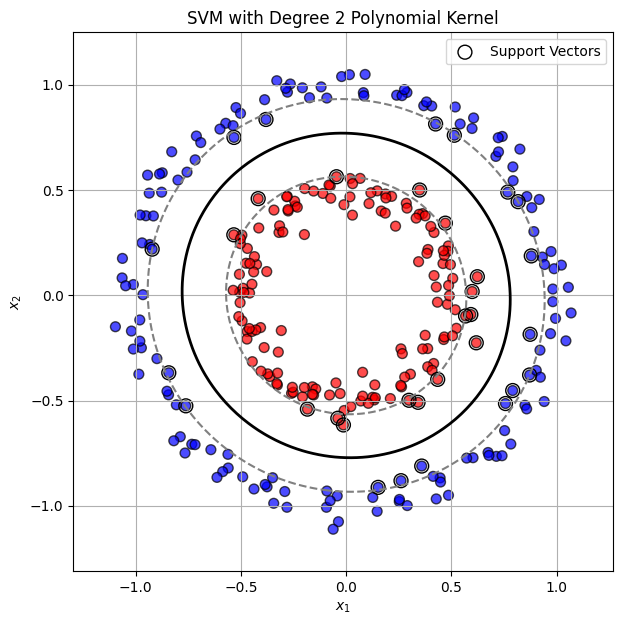

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles

# 1. Generate Data (Concentric Circles for Non-Linear Separation)
np.random.seed(42)
X, y = make_circles(n_samples=300, factor=0.5, noise=0.05)

# Convert labels from (0,1) to (-1,1) for SVM
y = np.where(y == 0, -1, 1)
#print(X)
#print(y)

# 2. Train SVM with Polynomial Kernel (Degree 2, c=0)
clf = SVC(kernel='poly', degree=2, C=1.0, coef0=0, gamma=1)
# scikit uses a complex scaled gamma for the kernels. Here we want to use non-optimal (but simplest!) kernels
# K(x, x') = (x^T x')^2
clf.fit(X, y)

# 3. Create Meshgrid for Plotting Decision Boundary
x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Flatten and Stack Grid for Prediction
grid = np.c_[xx.ravel(), yy.ravel()]
decision = clf.decision_function(grid)
decision = decision.reshape(xx.shape)

print(grid)


# 4. Plot Data Points and Decision Boundary
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', s=50, alpha=0.7)

# Plot Decision Boundary and Margins
plt.contour(xx, yy, decision, levels=[0], linewidths=2, colors='k')
plt.contour(xx, yy, decision, levels=[-1, 1], linestyles='--', colors='grey')

# Highlight Support Vectors
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=100, linewidth=1, facecolors='none', edgecolors='k', label='Support Vectors')

plt.title('SVM with Degree 2 Polynomial Kernel')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid(True)

plt.gca().set_aspect('equal')  #  making the plot square
plt.show()



### Task

By the way, if you were not to use the kernels, but rather engineer features allowing for the linear separation of the points, what would it be?

(array([-1.,  1.]), array([7177, 2823]))


<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\s'
C:\Users\elg23\AppData\Local\Temp\ipykernel_2216\1751813999.py:25: SyntaxWarning: invalid escape sequence '\p'
  ax.set_title('Explicit Mapping $\phi(x) = [x_1^2, \sqrt{2} x_1 x_2, x_2^2]$ with Decision Boundary')
C:\Users\elg23\AppData\Local\Temp\ipykernel_2216\1751813999.py:27: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel('$\sqrt{2} x_1 x_2$')


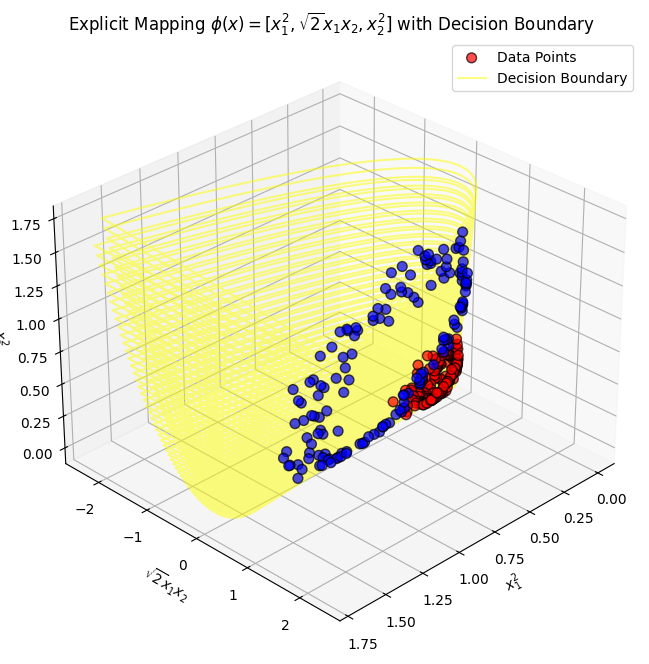

In [ ]:

# 3D Plot for phi(x) with Decision Boundary
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 5. Visualize Explicit Mapping phi(x) = [x1^2, sqrt(2) x1 x2, x2^2]

# Apply phi(x) to each point
phi_X = np.array([[x[0]**2, np.sqrt(2)*x[0]*x[1], x[1]**2] for x in X])

# Apply phi(x) to the meshgrid for decision boundary
phi_grid = np.array([[x[0]**2, np.sqrt(2)*x[0]*x[1], x[1]**2] for x in grid])

# Scatter plot of transformed data
ax.scatter(phi_X[:, 0], phi_X[:, 1], phi_X[:, 2], c=y, cmap='bwr', edgecolors='k', s=50, alpha=0.7, label='Data Points')

# Plot only the decision boundary contour (i.e. where decision == 0)
grid_decision = clf.decision_function(grid)
print(np.unique(np.sign(grid_decision), return_counts=True))
contour_mask = np.ones_like(grid_decision, dtype=bool)
#contour_mask = np.isclose(grid_decision, 0, atol=0.01)  # select points near decision boundary
ax.plot(phi_grid[contour_mask, 0], phi_grid[contour_mask, 1], phi_grid[contour_mask, 2],
           color='yellow', alpha=0.5 , label='Decision Boundary')

# Set axis labels and title for 3D plot
ax.set_title('Explicit Mapping $\phi(x) = [x_1^2, \sqrt{2} x_1 x_2, x_2^2]$ with Decision Boundary')
ax.set_xlabel('$x_1^2$')
ax.set_ylabel('$\sqrt{2} x_1 x_2$')
ax.set_zlabel('$x_2^2$')

ax.view_init(30, 45)

# Add legend and grid
ax.legend()
ax.grid(True)

plt.show()

print()


# **Homework Assignment: Polynomial Kernel SVM in 3D Feature Space**
-------------------------------
You have seen how a polynomial kernel of degree 2 can map the original 2D data
$$(x_1, x_2)$$
to a 3D feature space via some transformation
$$
\phi(\mathbf{x}).
$$
You also saw that **the decision boundary** in the 3D space—expected to be a hyperplane—**appears** as a circular surface when visualized.

## **Primary Question**

**Why does the SVM's decision boundary in the higher-dimensional (3D) feature space *not* look like a “flat” hyperplane,**
even though we *know* the classifier’s separating surface *is* mathematically linear in that space?

## **Secondary Question**

Explain **why** a hyperplane in 3D becomes a **circular (or elliptical) curve** when viewed back in the original 2D plane of the dataset.

## **Task & Deliverables**

1. **Colab Notebook**  
   - Create a **Colab notebook** that:
     - Clearly **answers** both the **primary** and **secondary** questions with appropriate plots and short explanations.
     - Uses Python code to visualise and create plots.
   - Include a discussion (in markdown cells) illustrating the geometry behind the mapping
     $$\phi(\mathbf{x})$$
     and the resulting decision boundary.
   - Use
     `$` symbol to delimit inline equations and `$$` to delimit full-line equations.

2. **Publish on GitHub**  
   - Place the Colab notebook in your **GitHub repository** for this course.
   - In your repository’s **README**, add a **link** to the notebook and also include an **“Open in Colab”** badge at the top of the notebook so it can be launched directly from GitHub.




### **Primary Question**
**Why does the SVM's decision boundary in the higher-dimensional (3D) feature space *not* look like a “flat” hyperplane,**
even though we *know* the classifier’s separating surface *is* mathematically linear in that space?

Granica decyzyjna w omawianym problemie zwizualizowana w 3D nie wygląda jak płaszczyzna zanurzona w 3D. Dlaczego? W końcu zgodnie z treścią zajęć oczekowalibyśmy, że nasz klasyfikator powinien znaleźć taką płaszczynę, która pozwala pozdzielić przestrzeń 3D na 2 części - jedna powinna zawierać tylko punkty należące do grupy pierwszej, a druga powinna zawierać tylko punkty grupy drugiej.

Poszukując odpowiedzi na to pytanie, warto zastanowić się, w pierwszej kolejności, jaki w ogóle jest obraz dwuwymiarowej płaszczyzny $(x_1, x_2)$ względem przekształcenia $\phi (x)$? Wizualizację takiego przekształcenia przedstawia poniższy rysunek. Widzimy, że płaszczyzna $(x_1, x_2)$ zostaje przekształcona w dwuwymiarową rozmaitość zanurzoną w przestrzeni 3D, która jednak nie jest płaska, ale posiada znacznie mniej oczywisty kształt (paraboloidy?). Oczywiste jest zatem, że jeżeli w poprzedniej wizualizacji granicy decyzyjnej wybieramy jedynie punkty z obrazu płaszczyzny $(x_1, x_2)$ względem przekształcenia $\phi (x)$, nie możemy zobaczyć granicy w postaci płaszczyzny, bo żadna płaszczyzna nie należy do obrazu przekształcenia $\phi (x)$.

**Co w takim razie obserwujemy?**

Rozsądnym przypuszczeniem wydaje się, że obserwowany okrąg obrazujący granicę decyzyjną w przestrzeni 3D jest przecięciem płaszczyzny stanowiącej granicę decyzyjną w pełnej przestrzeni 3D z obrazem płaszczyzny $(x_1, x_2)$ względem przekształcenia $\phi (x)$. Zobaczyć to możemy na następnym wykresie, na którym wyświatlam przywołany już okrąg, wizualizujący już omawianą granicę decyzyjną pochodzącą z przestrzeni 2D (w postaci okręgu), oraz granicę decyzyjną wyznaczoną bezpośrednio w przestrzeni 3D według modelu `SVC(kernel="linear")`, zastosowanego do zbioru punków już poprzednio przekształconego przez przekształcenie $\phi (x)$. Widzimy na nim, że istotnie czarne punkty okręgu granicy decyzyjnej wyciągnięte z modelu wytrenowanego na danych z przestrzeni 2D leżą dokładnie na pełnej płaszczyźnie wyznaczonej z modelu o jądrze liniowym trenowanym już na danych przekształconych przez $\phi (x)$, znajdujących się w przestrzeni 3D.

**Podsumowując:**

Obserwujemy przecięcie obrazu dwuwymiarowej przestrzeni $(x_1, x_2)$ względem przekształcenia $\phi (x)$ z pełną, "płaską" płaszczyzną rozdzielajacą punkty w przestrzeni 3D.

In [ ]:
#Train model

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles

# 1. Generate Data (Concentric Circles for Non-Linear Separation)
np.random.seed(42)
X, y = make_circles(n_samples=100, factor=0.5, noise=0.05)

# Convert labels from (0,1) to (-1,1) for SVM
y = np.where(y == 0, -1, 1)
#print(X)
#print(y)

# 2. Train SVM with Polynomial Kernel (Degree 2, c=0)
clf = SVC(kernel='poly', degree=2, C=1.0, coef0=0, gamma=1)
# scikit uses a complex scaled gamma for the kernels. Here we want to use non-optimal (but simplest!) kernels
# K(x, x') = (x^T x')^2
clf.fit(X, y)

,C,1.0
,kernel,'poly'
,degree,2
,gamma,1
,coef0,0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


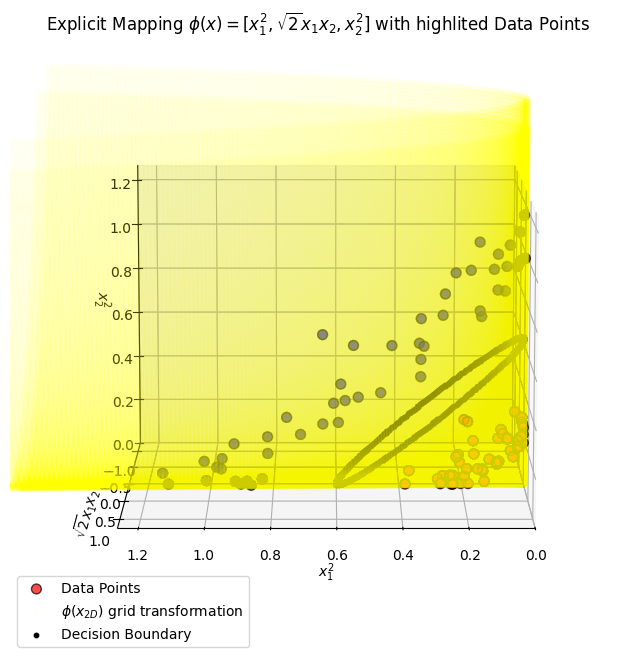

In [ ]:
#Plot the results

# 3. Create Meshgrid for Plotting Decision Boundary
x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))

# Flatten and Stack Grid for Prediction
grid = np.c_[xx.ravel(), yy.ravel()]
decision = clf.decision_function(grid)
decision = decision.reshape(xx.shape)


# 3D Plot for phi(x) with Decision Boundary
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 5. Visualize Explicit Mapping phi(x) = [x1^2, sqrt(2) x1 x2, x2^2]

def phi(x):
    return [x[0]**2, np.sqrt(2)*x[0]*x[1], x[1]**2]

# Apply phi(x) to each point
phi_X = np.array([phi(x) for x in X])

# Apply phi(x) to the meshgrid for decision boundary
phi_grid = np.array([phi(x) for x in grid])

# Scatter plot of transformed data
ax.scatter(phi_X[:, 0], phi_X[:, 1], phi_X[:, 2], c=y, cmap='bwr', edgecolors='k', s=50, alpha=0.7, label='Data Points')

# Plot only the decision boundary contour (i.e. where decision == 0)
grid_decision = clf.decision_function(grid)

ax.scatter(phi_grid[:, 0], phi_grid[:, 1], phi_grid[:, 2],
           color='yellow', alpha=0.02 , label='$\\phi (x_{2D})$ grid transformation')

contour_mask = np.isclose(grid_decision, 0, atol=0.01)  # select points near decision boundary
decision_boundary2d = phi_grid[contour_mask]

ax.scatter(phi_grid[contour_mask, 0], phi_grid[contour_mask, 1], phi_grid[contour_mask, 2],
           c='k', s=10, alpha=1, label='Decision Boundary')

# Set axis labels and title for 3D plot
ax.set_title('Explicit Mapping $\\phi(x) = [x_1^2, \\sqrt{2} x_1 x_2, x_2^2]$ with highlited Data Points')
ax.set_xlabel('$x_1^2$')
ax.set_ylabel('$\\sqrt{2} x_1 x_2$')
ax.set_zlabel('$x_2^2$')
ax.set_xlim(0, x_max)
ax.set_ylim(y_min, y_max)
ax.set_zlim(0, x_max)

ax.view_init(10, 90)

# Add legend and grid
ax.legend()
ax.grid(True)

plt.show()

print()


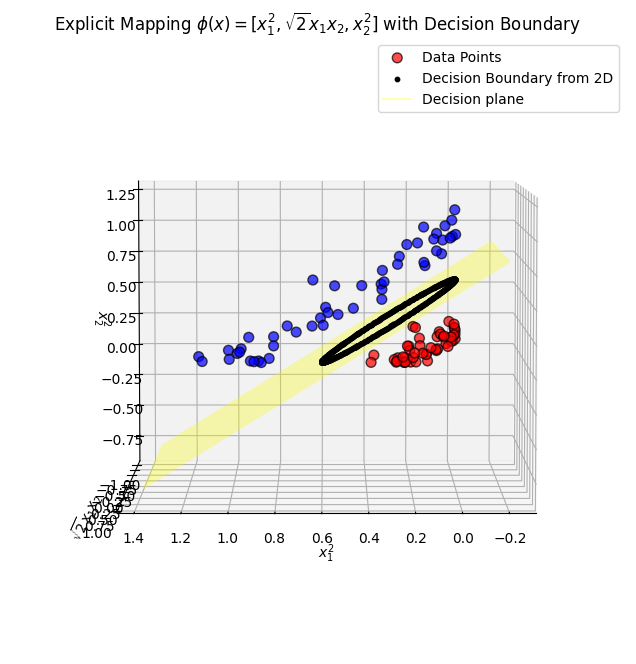

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles
from mpl_toolkits.mplot3d import Axes3D

# Explicit mapping phi(x)
phi_X = np.array([phi(x) for x in X])

# 2. Train SVM with Linear Kernel
clf3d = SVC(kernel='linear', C=1.0)
clf3d.fit(phi_X, y)

# 3. Create Meshgrid for Decision Boundary
x_min, x_max = phi_X[:, 0].min() - 0.2, phi_X[:, 0].max() + 0.2
y_min, y_max = phi_X[:, 1].min() - 0.2, phi_X[:, 1].max() + 0.2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 40),
    np.linspace(y_min, y_max, 40),
)

phi_grid = np.c_[xx.ravel(), yy.ravel()]
#print(phi_grid)

w = clf3d.coef_[0]      # [w1, w2]
b = clf3d.intercept_[0] # scalar bias

# Decision boundary: w^T x + b = 0 ==> x3 = -(w1*x1 + w2*x2 + b)/w3
def plane_z(x, offset=0.0):
    return -(w[0]*x[0] + w[1]*x[1] + (b - offset)) / w[2]


# 3D Plot for phi(x) with Decision Boundary
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of transformed data
ax.scatter(phi_X[:, 0], phi_X[:, 1], phi_X[:, 2], c=y, cmap='bwr', edgecolors='k', s=50, alpha=0.7, label='Data Points')

ax.scatter(decision_boundary2d[:, 0], decision_boundary2d[:, 1], decision_boundary2d[:, 2], c='k', s=10, alpha=1, label='Decision Boundary from 2D')
# Set axis labels and title for 3D plot
ax.plot(phi_grid[:, 0], phi_grid[:, 1], [plane_z(phi_grid[i]) for i in range(phi_grid.shape[0])], alpha=0.3, color="yellow", label="Decision plane")
ax.set_title('Explicit Mapping $\\phi(x) = [x_1^2, \\sqrt{2} x_1 x_2, x_2^2]$ with Decision Boundary')
ax.set_xlabel('$x_1^2$')
ax.set_ylabel('$\\sqrt{2} x_1 x_2$')
ax.set_zlabel('$x_2^2$')
ax.view_init(elev=5, azim=90)  # ustawienie kierunku patrzenia

# Add legend and grid
ax.legend()
ax.grid(True)

plt.show()


## **Secondary Question**

Explain **why** a hyperplane in 3D becomes a **circular (or elliptical) curve** when viewed back in the original 2D plane of the dataset.

Okrąg obserwowany jako granica decyzyjna w przestrzeni 2D jest po prostu przeciwobrazem (preimage) pewnego obiektu geometrycznego istniejącego w przestrzeni trzech wymiarów. W pełnej przestrzeni cech $\phi (x)$ klasyfikator SVM z jądrem wielomianowym stopnia 2 wyznacza płaską hiperpowierzchnię decyzyjną. Jednak dane po przekształceniu $\phi (x)$ nie wypełniają całej przestrzeni 3D, lecz leżą na zakrzywionej dwuwymiarowej rozmaitości będącej obrazem płaszczyzny $(x_1, x_2)$. W rezultacie widoczna w wizualizacji 3D krzywa nie jest pełną płaszczyzną decyzyjną, lecz jedynie przecięciem tej płaszczyzny z zakrzywioną powierzchnią, będącą obrazem wyjściowej przestrzeni 2D względem $\phi (x)$. To przecięcie ma postać krzywej stożkowej, okręgu lub elipsy, i właśnie tę krzywą obserwujemy na wykresie. Po odwzorowaniu jej z powrotem do przestrzeni oryginalnej otrzymujemy dokładnie tę samą nieliniową granicę decyzyjną, którą widzimy w 2D (jako okrąg lub elipsa). Innymi słowy, granica decyzyjna w 2D jest przeciwobrazem przecięcia liniowej hiperpowierzchni decyzyjnej w 3D z zakrzywionym obrazem płaszczyzny $(x_1, x_2)$ względem przekształcenia $\phi (x)$. Dlatego w 2D widzimy okrąg, a w 3D jedynie jego odpowiednik leżący na zakrzywionej powierzchni, a nie pełną płaszczyznę.